In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wfdb
import torch
import logging

import config
import data_load as dl
import data_pipeline as dp

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("Test-Pipeline")
log.info("All modules imported successfully. Starting pipeline test...")


15:57:28 | INFO     | All modules imported successfully. Starting pipeline test...


In [17]:
log.info("--- TESTING STEP 1: METADATA ---")

try:
    meta = dl.load_metadata(config.CFG["data_dir"])
    log.info(f"Metadata loaded. Shape: {meta.shape}")
    assert meta.shape[0] > 0, "Empty metadata!"
    log.info(f"Columns: {list(meta.columns)}")
    display(meta.head(3))
except Exception as e:
    log.error(f"FAILED: {e}")
    raise


16:06:13 | INFO     | --- TESTING STEP 1: METADATA ---
16:06:13 | INFO     | Loading metadata from D:\DEPI\ECG project\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\ptbxl_database.csv...
16:06:14 | INFO     | Dropped 0 duplicate records. 21799 records remain.
16:06:14 | INFO     | Masked ages (300 -> NaN): 293 patients aged >89.
16:06:14 | INFO     | Metadata loaded. Shape: (21799, 27)
16:06:14 | INFO     | Columns: ['patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human', 'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr']


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr


In [5]:
log.info("--- TESTING STEP 2: DUPLICATE-ID VERIFICATION ---")

dropped = config.DROPPED_ECG_IDS
still_present = [eid for eid in dropped if eid in meta.index]

if still_present:
    log.error(f"LEAKAGE: {len(still_present)} dropped IDs still in metadata: {still_present}")
    raise AssertionError("Duplicate ECG records found in metadata!")
else:
    log.info(f"Verified: all {len(dropped)} duplicate IDs correctly removed from metadata.")


15:57:28 | INFO     | --- TESTING STEP 2: DUPLICATE-ID VERIFICATION ---
15:57:28 | INFO     | Verified: all 38 duplicate IDs correctly removed from metadata.


In [ ]:
log.info("--- TESTING STEP 3: SCP STATEMENTS (FIXED) ---")

try:
    scp_diag = dl.load_scp_statements(config.CFG["data_dir"])

    assert (scp_diag["diagnostic"] == 1).all(),         "Non-diagnostic codes present — scp_diag is not filtered correctly!"

    log.info(f"SCP diagnostic table: {scp_diag.shape[0]} codes, "
             f"{scp_diag['diagnostic_class'].nunique()} superclasses.")
    display(scp_diag.head())

except Exception as e:
    log.error(f"FAILED: {e}")
    raise


15:57:28 | INFO     | --- TESTING STEP 3: SCP STATEMENTS (FIXED) ---
15:57:28 | INFO     | SCP diagnostic codes loaded: 44 codes across 5 superclasses.
15:57:28 | INFO     | SCP diagnostic table: 44 codes, 5 superclasses.


,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7


In [7]:
log.info("--- TESTING STEP 4: LABEL MATRIX ---")

try:
    Y, mlb, class_names, meta_labeled = dp.build_label_matrix(
        meta,
        scp_diag,                        # ← correctly filtered table
        threshold=config.CFG["label_thresh"]
    )

    assert Y.ndim == 2 and Y.shape[1] == len(class_names)
    assert Y.dtype == np.float32

    log.info(f"Label matrix shape : {Y.shape}")
    log.info(f"Classes detected   : {class_names}")

    counts = Y.sum(axis=0)
    for cls, cnt in zip(class_names, counts):
        log.info(f"  {cls:<6}: {int(cnt):>6} records ({100*cnt/len(meta_labeled):.1f}%)")

except Exception as e:
    log.error(f"FAILED: {e}")
    raise


15:57:28 | INFO     | --- TESTING STEP 4: LABEL MATRIX ---
15:57:29 | INFO     | Records with >=1 diagnostic label: 21375 (424 dropped).
15:57:29 | INFO     | Label matrix Y shape: (21375, 5) | Classes: ['CD', 'HYP', 'MI', 'NORM', 'STTC']
15:57:29 | INFO     | Class CD    :   4898 (22.9%)
15:57:29 | INFO     | Class HYP   :   2649 (12.4%)
15:57:29 | INFO     | Class MI    :   5469 (25.6%)
15:57:29 | INFO     | Class NORM  :   9514 (44.5%)
15:57:29 | INFO     | Class STTC  :   5108 (23.9%)
15:57:29 | INFO     | Label matrix shape : (21375, 5)
15:57:29 | INFO     | Classes detected   : ['CD', 'HYP', 'MI', 'NORM', 'STTC']
15:57:29 | INFO     |   CD    :   4898 records (22.9%)
15:57:29 | INFO     |   HYP   :   2649 records (12.4%)
15:57:29 | INFO     |   MI    :   5469 records (25.6%)
15:57:29 | INFO     |   NORM  :   9514 records (44.5%)
15:57:29 | INFO     |   STTC  :   5108 records (23.9%)


In [8]:
log.info("--- TESTING STEP 5: MISSING METADATA ---")

try:
    dl.inspect_missing_metadata(meta_labeled)
    log.info("Missing metadata inspection completed.")
except Exception as e:
    log.error(f"FAILED: {e}")
    raise


15:57:29 | INFO     | --- TESTING STEP 5: MISSING METADATA ---
15:57:29 | INFO     | Missing metadata inspection completed.



[2] Metadata missing values:
pacemaker                 21362 (99.9%)
electrodes_problems       21347 (99.9%)
infarction_stadium2       21272 (99.5%)
burst_noise               20795 (97.3%)
baseline_drift            19797 (92.6%)
extra_beats               19493 (91.2%)
static_noise              18169 (85.0%)
infarction_stadium1       15775 (73.8%)
height                    14469 (67.7%)
weight                    12022 (56.2%)
validated_by               9092 (42.5%)
heart_axis                 8147 (38.1%)
nurse                      1437 (6.7%)
age                         284 (1.3%)
site                         16 (0.1%)


In [9]:
log.info("--- TESTING STEP 6: SIGNAL CLEANING ---")

try:
    sample_id   = meta_labeled.index[0]
    sample_path = os.path.join(config.CFG["data_dir"],
                               meta_labeled.loc[sample_id, "filename_hr"])

    sig_raw, fields = wfdb.rdsamp(sample_path)
    log.info(f"Raw signal for ECG {sample_id}: shape={sig_raw.shape}, "
             f"fs={fields['fs']} Hz")

    sig_clean = dp.clean_single_signal(sig_raw)

    if sig_clean is None:
        log.warning("Signal marked corrupted — try a different sample.")
    else:
        assert sig_clean.shape == sig_raw.shape
        assert np.isfinite(sig_clean).all(), "NaN/Inf values remain after cleaning!"
        log.info(f"clean_single_signal passed. Shape: {sig_clean.shape}")

except Exception as e:
    log.error(f"FAILED: {e}")
    raise


15:57:29 | INFO     | --- TESTING STEP 6: SIGNAL CLEANING ---
15:57:29 | INFO     | Raw signal for ECG 1: shape=(5000, 12), fs=500 Hz
15:57:29 | INFO     | clean_single_signal passed. Shape: (5000, 12)


15:57:29 | INFO     | --- TESTING STEP 7: BANDPASS FILTER ---
15:57:29 | INFO     | bandpass_filter_single passed. Shape: (5000, 12)


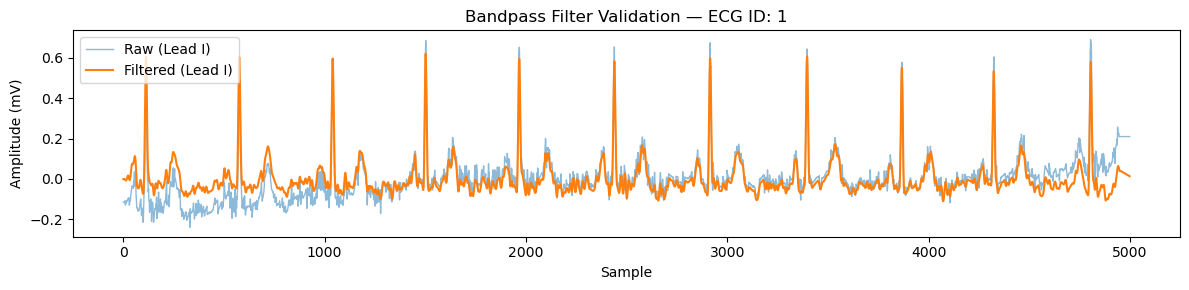

In [10]:
log.info("--- TESTING STEP 7: BANDPASS FILTER ---")

try:
    sig_filt = dp.bandpass_filter_single(
        sig_clean,
        fs=config.CFG["sampling_rate"],
        low=config.CFG["bandpass_low"],
        high=config.CFG["bandpass_high"],
        order=config.CFG["bandpass_ord"]
    )

    assert sig_filt.shape == sig_clean.shape
    assert np.isfinite(sig_filt).all()
    log.info(f"bandpass_filter_single passed. Shape: {sig_filt.shape}")

    plt.figure(figsize=(12, 3))
    plt.plot(sig_raw[:, 0],   label="Raw (Lead I)",      alpha=0.5, linewidth=1)
    plt.plot(sig_filt[:, 0],  label="Filtered (Lead I)", linewidth=1.5)
    plt.title(f"Bandpass Filter Validation — ECG ID: {sample_id}")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude (mV)")
    plt.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    log.error(f"FAILED: {e}")
    raise


In [11]:
log.info("--- TESTING STEP 8: RESAMPLE ---")

try:
    # Simulate loading 100 Hz signal and resampling to 500 Hz
    orig_fs, target_fs = 100, 500
    # Downsample the 500 Hz signal by 5 to get a fake 100 Hz signal
    sig_100hz = sig_clean[::5, :]
    log.info(f"Simulated 100 Hz signal shape: {sig_100hz.shape}")

    sig_resampled = dp.resample_single_signal(sig_100hz, orig_fs=orig_fs, target_fs=target_fs)

    expected_len = int(sig_100hz.shape[0] * (target_fs / orig_fs))
    assert sig_resampled.shape[0] == expected_len,         f"Expected {expected_len} samples, got {sig_resampled.shape[0]}"
    assert sig_resampled.shape[1] == sig_clean.shape[1]
    log.info(f"resample_single_signal passed: {sig_100hz.shape} → {sig_resampled.shape}")

    # No-op test
    sig_noop = dp.resample_single_signal(sig_clean, orig_fs=500, target_fs=500)
    assert sig_noop.shape == sig_clean.shape
    log.info("No-op resample (500→500) passed.")

except Exception as e:
    log.error(f"FAILED: {e}")
    raise


15:57:30 | INFO     | --- TESTING STEP 8: RESAMPLE ---
15:57:30 | INFO     | Simulated 100 Hz signal shape: (1000, 12)
15:57:30 | INFO     | resample_single_signal passed: (1000, 12) → (5000, 12)
15:57:30 | INFO     | No-op resample (500→500) passed.


In [18]:
log.info("--- TESTING STEP 9: NORMALIZE ---")

try:
    # ── Z-score ──
    sig_z = dp.normalize_single_signal(sig_clean, method="zscore")
    assert sig_z.shape == sig_clean.shape
    assert sig_z.dtype == np.float32

    lead_means = sig_z.mean(axis=0)
    lead_stds  = sig_z.std(axis=0)
    assert np.allclose(lead_means, 0, atol=0.05), f"Z-score means not ~0: {lead_means}"
    assert np.allclose(lead_stds,  1, atol=0.1),  f"Z-score stds not ~1: {lead_stds}"
    assert sig_z.min() >= -5.0 and sig_z.max() <= 5.0, "Clip bounds exceeded!"
    log.info("Z-score normalization passed. Mean≈0, Std≈1, values in [-5, 5].")

    # ── Min-max ──
    sig_mm = dp.normalize_single_signal(sig_clean, method="minmax")
    assert sig_mm.dtype == np.float32
    assert sig_mm.min() >= 0.0 and sig_mm.max() <= 1.0 + 1e-6
    log.info("Min-max normalization passed. Values in [0, 1].")

except Exception as e:
    log.error(f"FAILED: {e}")
    raise


16:09:42 | INFO     | --- TESTING STEP 9: NORMALIZE ---
16:09:42 | INFO     | Z-score normalization passed. Mean≈0, Std≈1, values in [-5, 5].
16:09:42 | INFO     | Min-max normalization passed. Values in [0, 1].


In [14]:
log.info("--- TESTING STEP 10: filter_corrupted_records ---")

try:
    # Run on a small slice for speed during testing
    SAMPLE_N = 50
    meta_sample = meta_labeled.iloc[:SAMPLE_N]
    log.info(f"Running QC Sweep on first {SAMPLE_N} records...")

    meta_clean = dl.filter_corrupted_records(
        meta_sample, config.CFG["data_dir"], fs=config.CFG["sampling_rate"]
    )

    dropped_n = SAMPLE_N - len(meta_clean)
    log.info(f"QC complete: {len(meta_clean)} clean / {dropped_n} corrupted in sample.")
    assert len(meta_clean) <= SAMPLE_N
    assert isinstance(meta_clean, pd.DataFrame)
    log.info("filter_corrupted_records passed.")

except Exception as e:
    log.error(f"FAILED: {e}")
    raise


16:04:59 | INFO     | --- TESTING STEP 10: filter_corrupted_records ---
16:04:59 | INFO     | Running QC Sweep on first 50 records...
16:04:59 | INFO     | Starting Quality Control Sweep... This might take a few minutes.
16:05:00 | INFO     | QC Sweep Finished! Dropped 0 corrupted records.
16:05:00 | INFO     | QC complete: 50 clean / 0 corrupted in sample.
16:05:00 | INFO     | filter_corrupted_records passed.


## Step 11 — Class Weights (Imbalance Handling)

In [15]:
log.info("--- TESTING STEP 11: compute_class_weights ---")

try:
    weights = dp.compute_class_weights(Y, class_names)

    assert isinstance(weights, dict)
    assert set(weights.keys()) == set(class_names), "Mismatch between weight keys and class names!"

    for cls, w in weights.items():
        assert w > 0, f"Non-positive weight for class {cls}"

    # Convert to tensor for BCEWithLogitsLoss pos_weight
    pos_weight_tensor = torch.tensor(
        [weights[c] for c in class_names], dtype=torch.float32
    )
    assert pos_weight_tensor.shape == (len(class_names),)
    log.info(f"pos_weight_tensor shape: {pos_weight_tensor.shape}")
    log.info(f"Weights: { {k: round(v,3) for k,v in weights.items()} }")
    log.info("compute_class_weights passed.")

except Exception as e:
    log.error(f"FAILED: {e}")
    raise


16:05:04 | INFO     | --- TESTING STEP 11: compute_class_weights ---
16:05:04 | INFO     | Class positive weights (for Loss Function):
16:05:04 | INFO     | Weight CD    : 3.364
16:05:04 | INFO     | Weight HYP   : 7.069
16:05:04 | INFO     | Weight MI    : 2.908
16:05:04 | INFO     | Weight NORM  : 1.247
16:05:04 | INFO     | Weight STTC  : 3.185
16:05:04 | INFO     | pos_weight_tensor shape: torch.Size([5])
16:05:04 | INFO     | Weights: {'CD': np.float32(3.364), 'HYP': np.float32(7.069), 'MI': np.float32(2.908), 'NORM': np.float32(1.247), 'STTC': np.float32(3.185)}
16:05:04 | INFO     | compute_class_weights passed.


## Step 12 — DataLoaders

In [16]:
log.info("--- TESTING STEP 12: DATALOADERS ---")

try:
    train_dl, val_dl, test_dl = dl.create_dataloaders(
        meta_labeled, Y, config.CFG["data_dir"]
    )

    log.info(f"Train batches: {len(train_dl)} | Val: {len(val_dl)} | Test: {len(test_dl)}")

    X_batch, Y_batch = next(iter(train_dl))
    bs   = config.CFG["batch_size"]
    n_cls = len(class_names)

    assert X_batch.shape == (bs, 12, 5000),         f"Expected ({bs}, 12, 5000), got {X_batch.shape}"
    assert Y_batch.shape == (bs, n_cls),         f"Expected ({bs}, {n_cls}), got {Y_batch.shape}"
    assert X_batch.dtype == torch.float32
    assert Y_batch.dtype == torch.float32

    log.info(f"X_batch: {X_batch.shape}  Y_batch: {Y_batch.shape}")
    log.info("DataLoader test passed.")

    log.info("=" * 60)
    log.info("ALL PIPELINE COMPONENTS (1–12) VERIFIED. READY FOR TRAINING.")
    log.info("=" * 60)

except Exception as e:
    log.error(f"FAILED: {e}")
    raise


16:05:07 | INFO     | --- TESTING STEP 12: DATALOADERS ---
16:05:07 | INFO     | Split (patient-wise via strat_fold):
16:05:07 | INFO     |   Train : 17073 patients
16:05:07 | INFO     |   Val   : 2145 patients
16:05:07 | INFO     |   Test  : 2157 patients
16:05:07 | INFO     | Train batches: 267 | Val: 34 | Test: 34
16:05:10 | INFO     | X_batch: torch.Size([64, 12, 5000])  Y_batch: torch.Size([64, 5])
16:05:10 | INFO     | DataLoader test passed.
16:05:10 | INFO     | ============================================================
16:05:10 | INFO     | ALL PIPELINE COMPONENTS (1–12) VERIFIED. READY FOR TRAINING.
16:05:10 | INFO     | ============================================================
